# TensorFlow Lite Demo Notebook

Dieses Notebook demonstriert, wie man mit TensorFlow Lite auf verschiedenen Plattformen (Windows CPU, Raspberry Pi, Jetson Orin Nano) arbeitet. Es beinhaltet:
- Installation der notwendigen Pakete
- Laden eines TFLite-Modells (MobileNetV2)
- Demo mit einem zufälligen Bild aus dem Internet
- Möglichkeit, ein eigenes Bild hochzuladen und zu klassifizieren
- Live-Videoklassifikation mit OpenCV


## Setup und Installation
Je nach Plattform werden die passenden Pakete installiert (TensorFlow oder tflite-runtime, OpenCV, Pillow, ipywidgets).

In [14]:
import sys, subprocess, platform, os

def install_packages():
    system = platform.system()
    if system == "Windows":
        # Windows Laptop (CPU-only)
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "tensorflow", "pillow", "opencv-python", "ipywidgets"])
    elif system == "Linux" and os.path.exists("/etc/nv_tegra_release"):
        # Jetson Orin Nano
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "tflite-runtime", "pillow", "opencv-python", "ipywidgets"])
    else:
        # Raspberry Pi oder andere Linux-Systeme
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "tflite-runtime", "pillow", "opencv-python", "ipywidgets"])

install_packages()

## Interpreter Loader Function
Eine Funktion, die je nach Plattform den passenden TFLite-Interpreter mit optionalen Delegates lädt (z.B. GPU-Delegate auf Jetson).

In [2]:
import platform, os

def load_interpreter(model_path):
    system = platform.system()
    try:
        # Versuch, tflite-runtime zu nutzen
        from tflite_runtime.interpreter import Interpreter, load_delegate
    except ImportError:
        # Fallback auf TensorFlow
        from tensorflow.lite import Interpreter, load_delegate

    delegates = []
    # Jetson Orin Nano erkennen
    if system == "Linux" and os.path.exists("/etc/nv_tegra_release"):
        delegates.append(load_delegate("libtensorflowlite_gpu_delegate.so"))
    # Interpreter mit Delegates (oder CPU-only)
    return Interpreter(model_path=model_path, experimental_delegates=delegates)


## Modell und Labels herunterladen
Wir verwenden das MobileNetV2 TFLite-Modell und die zugehörigen ImageNet-Labels.

In [3]:
import os
import urllib.request
import shutil

model_url  = "https://storage.googleapis.com/download.tensorflow.org/models/tflite_11_05_08/mobilenet_v2_1.0_224.tflite"
label_url  = "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
model_path = "mobilenet_v2_1.0_224.tflite"
labels_path= "ImageNetLabels.txt"

def download_with_ua(url, dest):
    """
    Ladet eine Datei von `url` herunter und schreibt sie nach `dest`,
    setzt einen Browser-User-Agent, um 403-Fehler zu vermeiden.
    """
    if os.path.exists(dest):
        print(f"{dest} existiert bereits, überspringe Download.")
        return
    print(f"Downloading {url} …")
    req = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    )
    with urllib.request.urlopen(req) as resp, open(dest, "wb") as out:
        shutil.copyfileobj(resp, out)
    print(f"Saved to {dest}")

# 1) Download Labels immer zuerst
try:
    download_with_ua(label_url, labels_path)
except Exception as e:
    print("Labels-Download fehlgeschlagen:", e)
    # hier könnte man noch einen Fallback auf ein lokales GitHub-Raw‐File o.ä. setzen

# 2) Model herunterladen oder fallback auf Keras-Konvertierung
try:
    download_with_ua(model_url, model_path)
except Exception as e:
    print("Model-Download fehlgeschlagen:", e)
    print("Versuche Fallback: Konvertiere MobileNetV2 aus tf.keras…")
    import tensorflow as tf
    keras_model = tf.keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        weights="imagenet",
        include_top=True
    )
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_model = converter.convert()
    with open(model_path, "wb") as f:
        f.write(tflite_model)
    print("Konvertierung fertig, TFLite-Modell unter", model_path)

# 3) Labels einlesen
if os.path.exists(labels_path):
    with open(labels_path, "r") as f:
        # Die erste Zeile ist meist ein Platzhalter, je nach Format ggfs. [1:]
        labels = [l.strip() for l in f.readlines()]
    print(f"{len(labels)} Labels geladen.")
else:
    raise FileNotFoundError(f"{labels_path} fehlt immer noch – bitte manuell nachladen.")

# Ab hier kannst Du Deinen Interpreter initialisieren und inferieren:
import numpy as np
import tensorflow as tf

# TFLite Interpreter laden
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Beispiel für Inferenz auf einem NumPy-Array
dummy_input = np.zeros(input_details[0]['shape'], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], dummy_input)
interpreter.invoke()
out = interpreter.get_tensor(output_details[0]['index'])
print("Dummy-Inference erfolgreich, Ausgabe-Shape:", out.shape)


ImageNetLabels.txt existiert bereits, überspringe Download.
mobilenet_v2_1.0_224.tflite existiert bereits, überspringe Download.
1001 Labels geladen.
Dummy-Inference erfolgreich, Ausgabe-Shape: (1, 1000)


C:\Users\marco.giangreco\.conda\envs\tflite\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Interpreter initialisieren
Interpreter laden, Tensoren allokieren und Input-/Output-Details auslesen.

In [4]:
import os
import platform

def load_interpreter(model_path: str):
    """
    Lädt einen TFLite-Interpreter. 
    1) Versuch, tflite_runtime zu importieren
    2) Fallback auf tensorflow.lite
    3) Optional: Edge-TPU- bzw. TensorRT-Delegate
    """
    # 1) Interpreter & load_delegate importieren
    try:
        # auf Pi oder allgemeinem tflite-runtime
        from tflite_runtime.interpreter import Interpreter, load_delegate
    except ImportError:
        # Fallback: tensorflow integriert
        import tensorflow as tf
        try:
            # neueres TF: tf.lite.Interpreter existiert
            Interpreter = tf.lite.Interpreter
            load_delegate = tf.lite.load_delegate
        except Exception:
            # ältere TF-Version: direkt aus internals
            from tensorflow.lite.python.interpreter import Interpreter, load_delegate

    # 2) Optional Delegates zusammenstellen
    delegates = []

    # Raspberry Pi + Coral Edge-TPU
    # (setzt voraus, dass libedgetpu.so.1 installiert ist)
    if platform.system() == "Linux" and "arm" in platform.machine():
        try:
            delegates.append(load_delegate("libedgetpu.so.1"))
            print("Edge-TPU Delegate geladen.")
        except Exception:
            pass

    # Jetson Orin Nano (TensorRT)
    # (setzt voraus, dass libnvinfer.so im LD_LIBRARY_PATH liegt)
    if platform.system() == "Linux" and "aarch64" in platform.machine():
        try:
            delegates.append(load_delegate("libnvinfer.so"))
            print("TensorRT Delegate geladen.")
        except Exception:
            pass

    # 3) Interpreter instanziieren
    # je nach tflite-runtime Version kann das Argument heißen:
    #   model_path=... oder einfach Pfad als erstes Argument
    try:
        interpreter = Interpreter(model_path=model_path,
                                  experimental_delegates=delegates)
    except TypeError:
        # älteres API
        interpreter = Interpreter(model_path, delegates)

    return interpreter

# Beispiel-Aufruf:
model_path = "mobilenet_v2_1.0_224.tflite"
interpreter = load_interpreter(model_path)
interpreter.allocate_tensors()

in_details  = interpreter.get_input_details()
out_details = interpreter.get_output_details()
print("Input shape:", in_details[0]['shape'])
print("Output details:", out_details)


Input shape: [  1 224 224   3]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 172, 'shape': array([   1, 1000], dtype=int32), 'shape_signature': array([  -1, 1000], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


## Demo: Zufälliges Bild aus dem Internet
Wir laden ein zufälliges Bild (224×224) und führen die Klassifikation durch.

In [5]:
!pip install matplotlib

Predicted class: pickup (index: 718 )


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

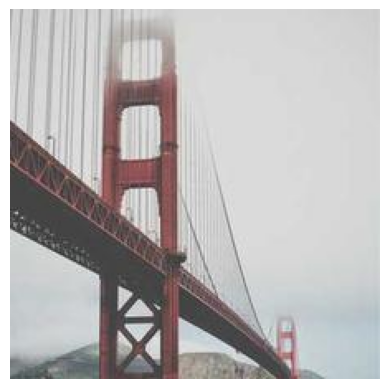

In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Zufallsbild abrufen
url = "https://picsum.photos/224"
resp = urllib.request.urlopen(url)
img = Image.open(resp).convert("RGB").resize((
    input_details[0]['shape'][1], input_details[0]['shape'][2]
))
input_data = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)

# Inferenz
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
pred_idx = np.argmax(output_data)
print("Predicted class:", labels[pred_idx], "(index:", pred_idx, ")")

# Bild anzeigen
plt.imshow(img)
plt.axis('off')


## Demo: Eigenes Bild hochladen und klassifizieren
Verwende das FileUpload-Widget, um ein eigenes Bild auszuwählen.

In [10]:
import io
from PIL import Image
import numpy as np
from ipywidgets import FileUpload, VBox

upload = FileUpload(accept='image/*', multiple=False)
display(upload)

def on_upload_change(change):
    if upload.value:
        content = next(iter(upload.value.values()))['content']
        img2 = Image.open(io.BytesIO(content)).convert("RGB").resize((
            input_details[0]['shape'][1], input_details[0]['shape'][2]
        ))
        input_data2 = np.expand_dims(np.array(img2, dtype=np.float32) / 255.0, axis=0)
        interpreter.set_tensor(input_details[0]['index'], input_data2)
        interpreter.invoke()
        output_data2 = interpreter.get_tensor(output_details[0]['index'])
        pred_idx2 = np.argmax(output_data2)
        print("Predicted class:", labels[pred_idx2], "(index:", pred_idx2, ")")
        display(img2)

upload.observe(on_upload_change, names='value')
VBox([upload])

FileUpload(value=(), accept='image/*', description='Upload')

## Demo: Live-Videoklassifikation mit OpenCV
Verwende die Webcam, um fortlaufend Frames zu klassifizieren. Drücke 'q' zum Beenden.

In [16]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
print("Press 'q' to quit.")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    # Frame vorbereiten
    img_cv = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_cv, (
        input_details[0]['shape'][1], input_details[0]['shape'][2]
    ))
    input_data3 = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)
    interpreter.set_tensor(input_details[0]['index'], input_data3)
    interpreter.invoke()
    output_data3 = interpreter.get_tensor(output_details[0]['index'])
    pred_idx3 = np.argmax(output_data3)
    label3 = labels[pred_idx3]
    # Label im Frame anzeigen
    cv2.putText(frame, label3, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                1, (0, 255, 0), 2)
    cv2.imshow("TFLite Classification", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit.
